In [89]:
from gdt.core import data_path
from gdt.missions.fermi.gbm.tte import GbmTte
from gdt.core.binning.unbinned import bin_by_time
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from gdt.core.plot.lightcurve import Lightcurve
from gdt.missions.fermi.time import Time

In [117]:
tte1 = 'glg_tte_n9_bn100414097_v01.fit'
tte2 = 'glg_tte_n9_bn090926914_v00.fit'
tte3 = 'glg_tte_n9_bn140519043_v00.fit'
tte4 = 'glg_tte_n9_bn130427324_v00(1).fit'
tte5 = 'glg_tte_n9_bn090902462_v00.fit' #mark
tte6 = 'glg_tte_n9_bn090902401_v00.fit'
tte7 = 'glg_tte_n9_bn080916406_v01.fit'
tte8 = 'glg_tte_n9_bn080916009_v01.fit'
tte9 = 'glg_tte_n9_bn090423330_v00(1).fit'
tte10 = 'glg_tte_n9_bn140619490_v00.fit'
tte11 = 'glg_tte_n9_bn090510016_v00.fit'
tte12 = 'glg_tte_n9_bn090510325_v00.fit'
tte13 = 'glg_tte_n9_bn140619475_v00.fit'
tte14 = 'glg_tte_n8_bn080916009_v01.fit'
tte15 = 'glg_tte_n9_bn090926181_v00.fit'
tte16 = 'glg_tte_n8_bn090423330_v00.fit'
tte17 = 'glg_tte_n7_bn090423330_v00.fit'
tte18 = 'glg_tte_n6_bn090423330_v00.fit'
tte19 = 'glg_tte_n5_bn090423330_v00.fit'
tte20 = 'glg_tte_n4_bn090423330_v00.fit'
tte21 = 'glg_tte_n3_bn090423330_v00.fit'
tte22 = 'glg_tte_n2_bn090423330_v00.fit'
tte23 = 'glg_tte_n1_bn090423330_v00.fit'
tteARCHIVE = 'archive-data/glg_tte_n8_bn080916009_v01(1).fit'
tte = GbmTte.open(tteARCHIVE)

In [118]:
fermi = tte.trigtime
fermi_met = Time(fermi, format='fermi')
fermi_met.iso
trig = fermi_met.value
trig

np.float64(243216766.613542)

In [119]:
273582310.0

273582310.0

In [120]:
phaii = tte.to_phaii(bin_by_time, 0.1, time_ref=0.0)
phaii

No.,Name,Ver,Type,Cards,Dimensions
0,PRIMARY,1,PrimaryHDU,30,()
1,EBOUNDS,1,BinTableHDU,47,128R x 3C
2,SPECTRUM,1,BinTableHDU,68,3267R x 5C
3,GTI,1,BinTableHDU,42,1R x 2C


In [121]:
phaii.get_column_names(3)

('START', 'STOP')

In [122]:
phaii.get_column_names(2)

('COUNTS', 'EXPOSURE', 'QUALITY', 'TIME', 'ENDTIME')

In [123]:
#filepath = data_path.joinpath('fermi-gbm/glg_tte_n9_bn090131090_v01.fit')
#tte_test = GbmTte.open(filepath)
#tte_test
#COMMENTED OUT IN ARCHIVE
#tte_test.get_column_names(2)

In [124]:
energy_sliced_tte = tte.slice_energy((8, 260.0))
energy_sliced_tte

No.,Name,Ver,Type,Cards,Dimensions
0,PRIMARY,1,PrimaryHDU,30,()
1,EBOUNDS,1,BinTableHDU,47,128R x 3C
2,EVENTS,1,BinTableHDU,42,261422R x 2C
3,GTI,1,BinTableHDU,42,1R x 2C


In [125]:
sliced_phaii = energy_sliced_tte.to_phaii(bin_by_time, 0.5, time_ref=0.0)
sliced_phaii

No.,Name,Ver,Type,Cards,Dimensions
0,PRIMARY,1,PrimaryHDU,30,()
1,EBOUNDS,1,BinTableHDU,47,128R x 3C
2,SPECTRUM,1,BinTableHDU,68,654R x 5C
3,GTI,1,BinTableHDU,42,1R x 2C


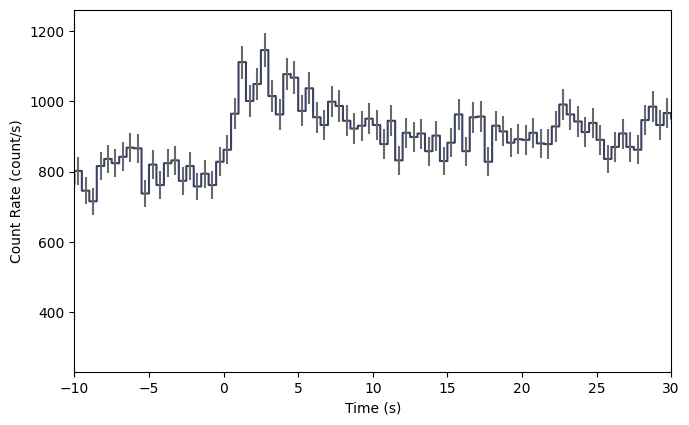

In [126]:
lcplot = Lightcurve(data=sliced_phaii.to_lightcurve())
plt.xlim(-10,30)
plt.show()

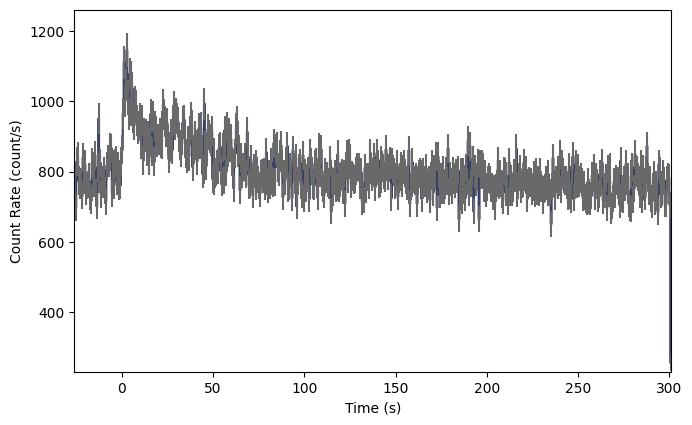

In [127]:
lcplot = Lightcurve(data=sliced_phaii.to_lightcurve())
plt.show()

In [128]:
time_counts = sliced_phaii.columns_as_array(2, ["TIME"])
len(time_counts)

654

In [129]:
sliced_counts_prime = sliced_phaii.columns_as_array(2, ["COUNTS"])
sliced_counts = np.zeros(len(sliced_counts_prime[0]))
for i in range(0, len(sliced_counts_prime)):
    for j in range(0, len(sliced_counts_prime[i])):
        #print(sliced_counts[j])
        #print(sliced_counts_prime[i][j][0])
        sliced_counts[j] = sliced_counts[j] + sliced_counts_prime[i][j][0]
len(sliced_counts)

654

In [116]:
#plt.scatter(time_counts,sliced_counts)

In [71]:
#time_counts = np.array([x**bin_width for x in range(0, len(sliced_counts))], dtype=np.float128)

In [72]:
#popt, _ = curve_fit(func, sliced_counts, time_counts)

In [73]:
max = [0,0]
for i in range(0, len(sliced_counts)):
    if sliced_counts[i] > max[0]:
        max[0] = sliced_counts[i]
        max[1] = time_counts[i]

In [74]:
max[1][0]

TypeError: 'int' object is not subscriptable

In [34]:
max[1].astype(float) - trig.astype(float)

AttributeError: 'int' object has no attribute 'astype'

In [35]:
max[0]

0

In [36]:
background_arr=sliced_counts[100:]

In [37]:
np.average(background_arr)

np.float64(0.0)

In [38]:
np.std(background_arr)

np.float64(0.0)

In [39]:
lightcurve = sliced_phaii.to_lightcurve()
counts = np.array(lightcurve.counts, dtype=np.float128)
time_counts = np.array([x**bin_width for x in range(0, len(counts))], dtype=np.float128)
max_count = [0,0]
for i in range(0, len(counts)):
    if counts[i] > max_count[0]:
        max_count[0] = counts[i]
        max_count[1] = time_counts[i]

NameError: name 'bin_width' is not defined

In [40]:
max_count[0]

NameError: name 'max_count' is not defined

In [81]:
set = 1
try:
    set = 0
    print(str(1/0))
except:
    print(oopsie)
finally:
    print(str(set))

0


NameError: name 'oopsie' is not defined

In [83]:
a="5"

In [85]:
np.array([a]).astype("float64")[0]

np.float64(5.0)

In [87]:
json_file = "data/grb_analysis.json"

In [88]:
import json

with open(json_file, 'r') as file:
    data = json.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'data/grb_analysis.json'